# Simulation deuxieme partie du stage


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats as stats
from typing import Tuple, Optional, Dict, List
from abc import ABC, abstractmethod
from enum import Enum

In [2]:
class NetworkTopology(Enum):
    ERDOS_RENYI = "erdos_renyi"
    SMALL_WORLD = "small_world"
    SCALE_FREE = "scale_free"



In [27]:
class BankingNetwork:
    """
    Classe pour générer et gérer un réseau bancaire avec différentes topologies.
    Conserve l'implémentation NetworkX propre et le mécanisme d'Eisenberg-Noe.
    """

    def __init__(self, number_bank: int, topology: NetworkTopology,
                 probability_of_linking: float = 0.1, **topology_params):
        self.number_bank = number_bank
        self.topology = topology
        self.probability_of_linking = probability_of_linking
        self.topology_params = topology_params

        # Structures de données (conservées de l'implémentation précédente)
        self.graph = None
        self.vector_outside_liabilities = None
        self.vector_outside_asset = None
        self.matrix_obligation = None
        self.matrix_relative_exposures = None

        # Génération du réseau
        self.generate()

    def generate(self):
        """Génère le réseau selon la topologie choisie."""
        # Génération du graphe
        if self.topology == NetworkTopology.ERDOS_RENYI:
            self.graph = self._generate_erdos_renyi()
        elif self.topology == NetworkTopology.SMALL_WORLD:
            self.graph = self._generate_small_world()
        elif self.topology == NetworkTopology.SCALE_FREE:
            self.graph = self._generate_scale_free()

        # Génération des bilans (méthode conservée)
        self._generate_balance_sheets()

    def _generate_erdos_renyi(self):
        """Génère un graphe Erdős-Rényi dirigé."""
        return nx.erdos_renyi_graph(
            n=self.number_bank,
            p=self.probability_of_linking,
            directed=True
        )

    def _get_calibrated_params(self):
        """Calibre automatiquement les paramètres selon le nombre de banques."""
        target_avg_degree = self.probability_of_linking * (self.number_bank - 1)

        params = {
            NetworkTopology.SMALL_WORLD: {
                'k': max(2, int(2 * target_avg_degree)),  # k doit être pair et ≥ 2
                'p': 0.3  # Bon compromis clustering/distance
            },
            NetworkTopology.SCALE_FREE: {
                'm': max(1, int(target_avg_degree / 2))  # m ≥ 1
            }
        }

        # Override avec paramètres utilisateur si fournis
        if self.topology in params:
            params[self.topology].update(self.topology_params)
            return params[self.topology]
        return {}

    def _generate_small_world(self):
        """Génère un graphe Small World dirigé avec calibrage automatique."""
        calibrated = self._get_calibrated_params()
        k, p = calibrated['k'], calibrated['p']

        # Assure que k est valide pour la taille du réseau
        k = min(k, self.number_bank - 1)
        if k % 2 == 1: k -= 1  # k doit être pair
        if k < 2: k = 2

        undirected = nx.watts_strogatz_graph(self.number_bank, k, p)
        return self._convert_to_directed(undirected)

    def _generate_scale_free(self):
        """Génère un graphe Scale-Free dirigé avec calibrage automatique."""
        calibrated = self._get_calibrated_params()
        m = min(calibrated['m'], self.number_bank - 1)  # m < n

        undirected = nx.barabasi_albert_graph(self.number_bank, m)
        return self._convert_to_directed(undirected, preferential=True)

    def _convert_to_directed(self, undirected_graph, preferential=False):
        """Convertit un graphe non-dirigé en dirigé de manière cohérente."""
        directed = nx.DiGraph()
        directed.add_nodes_from(range(self.number_bank))

        for u, v in undirected_graph.edges():
            # Direction aléatoire pour chaque arête
            if np.random.random() < 0.5:
                directed.add_edge(u, v)
            else:
                directed.add_edge(v, u)

            # Probabilité d'arête bidirectionnelle
            if preferential:
                # Pour scale-free : probabilité basée sur les degrés
                degree_sum = undirected_graph.degree(u) + undirected_graph.degree(v)
                prob_bidirectional = min(0.5, degree_sum / (4 * self.number_bank))
            else:
                # Pour small world : probabilité fixe
                prob_bidirectional = self.probability_of_linking * 0.3

            if np.random.random() < prob_bidirectional:
                if directed.has_edge(u, v):
                    directed.add_edge(v, u)
                else:
                    directed.add_edge(u, v)

        return directed

    def _generate_balance_sheets(self):
        """Génère les bilans bancaires (méthode conservée de ton implémentation)."""
        n = self.number_bank
        self.vector_outside_liabilities = np.zeros(n)
        self.vector_outside_asset = np.zeros(n)
        self.matrix_obligation = np.zeros((n, n))

        # Génération des passifs externes
        for i in range(n):
            if np.random.random() < self.probability_of_linking:
                self.vector_outside_liabilities[i] = stats.gamma.rvs(a=150)

        # Génération des obligations interbancaires
        for i, j in self.graph.edges():
            self.matrix_obligation[i][j] = stats.gamma.rvs(a=150)

        # Équilibrage des bilans et calcul des expositions relatives
        self._balance_sheets()

    def _balance_sheets(self):
        """Méthode conservée de ton implémentation."""
        je_dois = np.sum(self.matrix_obligation, axis=1)
        on_me_doit = np.sum(self.matrix_obligation, axis=0)

        for i in range(self.number_bank):
            deficit_total = je_dois[i] + self.vector_outside_liabilities[i] - on_me_doit[i]

            if deficit_total > 0:
                self.vector_outside_asset[i] = deficit_total + stats.gamma.rvs(a=200)
            else:
                self.vector_outside_asset[i] = stats.gamma.rvs(a=200)

        self._compute_relative_exposures()

    def _compute_relative_exposures(self):
        """Calcule la matrice relative d'exposition."""
        self.matrix_relative_exposures = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            total_du_par_i = np.sum(self.matrix_obligation[i, :])
            if total_du_par_i > 0:
                self.matrix_relative_exposures[i, :] = self.matrix_obligation[i, :] / total_du_par_i

    def compute_clearing_payments(self, shock_vector: np.array,
                                tolerance: float = 1e-9) -> np.array:
        """Méthode Eisenberg-Noe conservée."""
        due_payments = np.sum(self.matrix_obligation, axis=1)
        vector_of_payments = due_payments.copy()

        if np.all(shock_vector == 0):
            return vector_of_payments

        while True:
            new_vector_of_payments = np.minimum(
                due_payments,
                np.maximum(
                    self.matrix_relative_exposures.T @ vector_of_payments
                    - shock_vector
                    + self.vector_outside_asset,
                    0
                )
            )

            if np.allclose(new_vector_of_payments, vector_of_payments, rtol=tolerance):
                return new_vector_of_payments

            vector_of_payments = new_vector_of_payments



    def get_net_worth_after_clearing(self, shock_vector: np.array) -> Tuple[np.array, np.array]:
        """Calcule le net worth après clearing (méthode conservée)."""
        payments = self.compute_clearing_payments(shock_vector)
        updated_obligations = self.get_updated_obligation_matrix(payments)

        actifs_internes_effectifs = np.sum(updated_obligations, axis=0)

        net_worth = (
            (self.vector_outside_asset - shock_vector) +
            actifs_internes_effectifs -
            self.vector_outside_liabilities -
            payments
        )

        return net_worth, payments

    def get_updated_obligation_matrix(self, payments_vector: np.array) -> np.array:
        """Matrice d'obligations actualisée après clearing."""
        updated_matrix = np.zeros_like(self.matrix_obligation)

        for i in range(self.number_bank):
            updated_matrix[i, :] = payments_vector[i] * self.matrix_relative_exposures[i, :]

        return updated_matrix

    def count_defaults(self, shock_vector: np.array, threshold: float = 0.0) :
        """Compte les défauts après clearing."""
        net_worth, _ = self.get_net_worth_after_clearing(shock_vector)
        return np.mean(net_worth <= threshold)

    def compute_connectivity_metrics(self) -> Dict:
        """Calcule les métriques de connectivité pour comparaison entre topologies."""
        n = self.number_bank
        m = self.graph.number_of_edges()

        return {
            'density': m / (n * (n-1)) if n > 1 else 0,
            'avg_degree': 2*m / n if n > 0 else 0,
            'clustering': nx.average_clustering(self.graph) if n > 0 else 0,
            'max_degree': max(dict(self.graph.degree()).values()) if n > 0 else 0,
            'degree_variance': np.var(list(dict(self.graph.degree()).values())) if n > 0 else 0
        }


In [4]:
class ShockModel(ABC):
    """Classe abstraite pour les différents modèles de chocs."""

    @abstractmethod
    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un vecteur de chocs et retourne des métadonnées."""
        pass

In [5]:
class TargetedShockModel(ShockModel):
    """Modèle de choc ciblé (comme dans le papier de référence)."""

    def __init__(self, target_strategy: str = "systemic", shock_intensity: float = 1.0):
        self.target_strategy = target_strategy
        self.shock_intensity = shock_intensity

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un choc ciblé sur une banque spécifique."""
        target = self._select_target(network)

        shock_vector = np.zeros(network.number_bank)
        shock_vector[target] = self.shock_intensity * network.vector_outside_asset[target]

        metadata = {
            'type': 'targeted',
            'target': target,
            'target_strategy': self.target_strategy,
            'shock_size': shock_vector[target]
        }

        return shock_vector, metadata

    def _select_target(self, network: BankingNetwork) -> int:
        """Sélectionne la banque à cibler selon la stratégie."""
        if self.target_strategy == "max_degree":
            degrees = dict(network.graph.degree())
            return max(degrees, key=degrees.get)
        elif self.target_strategy == "max_assets":
            return np.argmax(network.vector_outside_asset)
        elif self.target_strategy == "systemic":
            scores = []
            for i in range(network.number_bank):
                degree = network.graph.degree(i)
                assets = network.vector_outside_asset[i]
                scores.append(degree * assets)
            return np.argmax(scores)
        else:  # random
            return np.random.randint(0, network.number_bank)


In [6]:
class CorrelatedShockModel(ShockModel):
    """Modèle de chocs corrélés avec facteur commun."""

    def __init__(self, correlation_strength: float = 1, crisis_prob: float = 0.1):
        self.correlation_strength = correlation_strength
        self.crisis_prob = crisis_prob

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère des chocs corrélés."""
        n = network.number_bank

        is_crisis = np.random.random() < self.crisis_prob
        alpha = 0.2 if is_crisis else self.correlation_strength

        common_factor = np.random.pareto(2.0)
        idiosyncratic = np.random.pareto(2.0, size=n)

        shock_intensities = alpha * common_factor + (1-alpha) * idiosyncratic
        shock_intensities = shock_intensities / np.max(shock_intensities) * 0.5  # Normalisation

        shock_vector = shock_intensities * network.vector_outside_asset

        metadata = {
            'type': 'correlated',
            'is_crisis': is_crisis,
            'correlation_strength': alpha,
            'common_factor': common_factor
        }

        return shock_vector, metadata


In [7]:
class LiquidityShockModel(ShockModel):
    """Modèle de choc de liquidité avec ventes forcées."""

    def __init__(self, distress_prob: float = 0.2, fire_sale_intensity: float = 0.5):
        self.distress_prob = distress_prob
        self.fire_sale_intensity = fire_sale_intensity

    def generate_shock(self, network: BankingNetwork) -> Tuple[np.array, Dict]:
        """Génère un choc de liquidité."""
        n = network.number_bank

        distressed = np.random.random(n) < self.distress_prob
        total_fire_sales = np.sum(network.vector_outside_asset[distressed])

        if total_fire_sales > 0:
            price_impact = np.exp(-self.fire_sale_intensity * total_fire_sales /
                                np.sum(network.vector_outside_asset))
        else:
            price_impact = 1.0

        shock_vector = (1 - price_impact) * network.vector_outside_asset

        metadata = {
            'type': 'liquidity',
            'distressed_banks': distressed,
            'price_impact': price_impact,
            'total_fire_sales': total_fire_sales
        }

        return shock_vector, metadata


GÉNÉRATION DES GRAPHIQUES
----------------------------------------

1. EFFET DE DIVERSIFICATION
Erdős-Rényi...


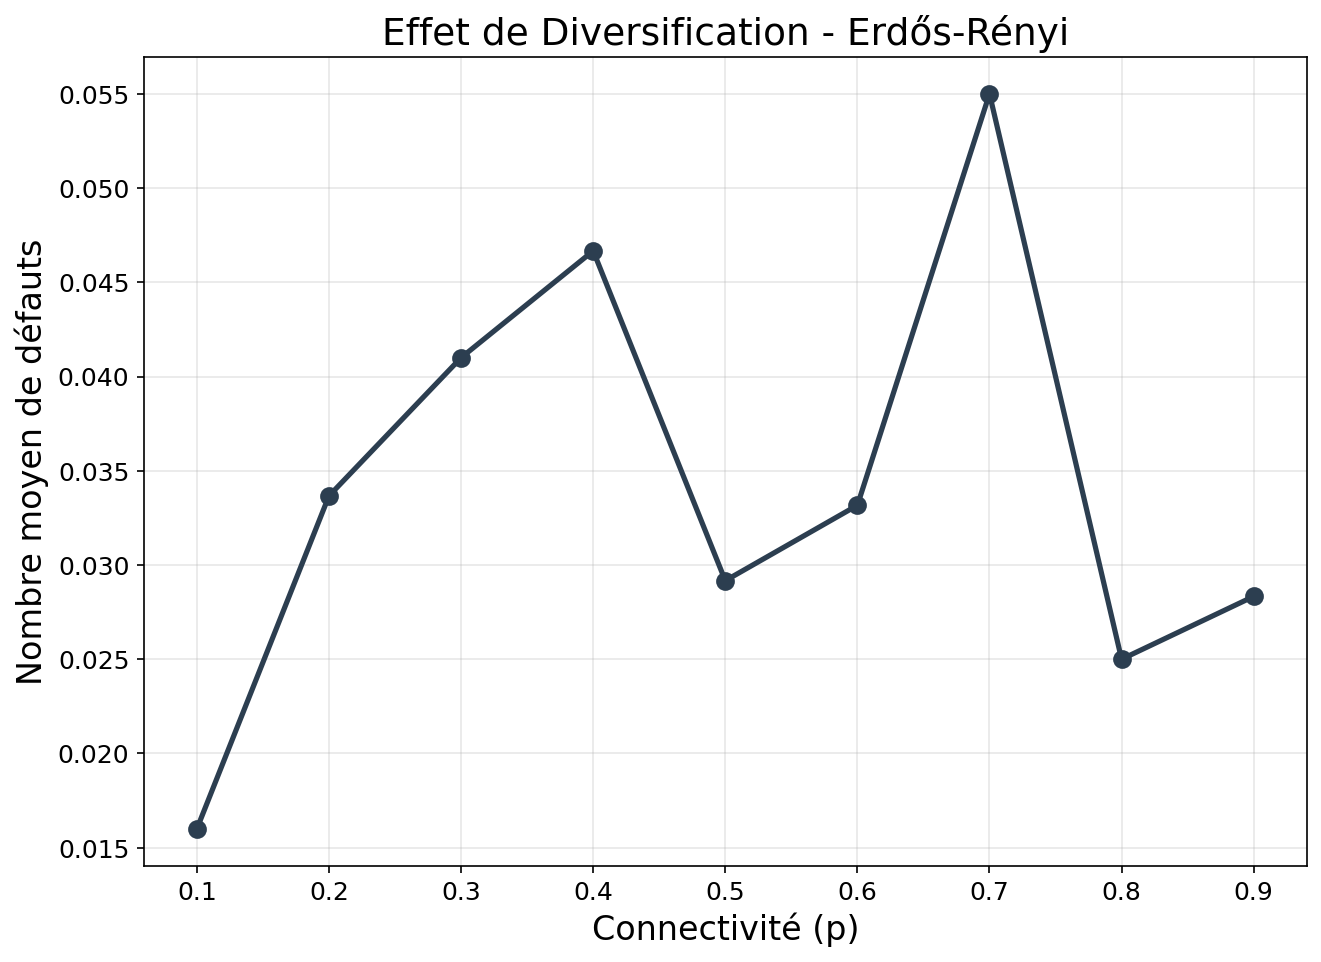

Small World...


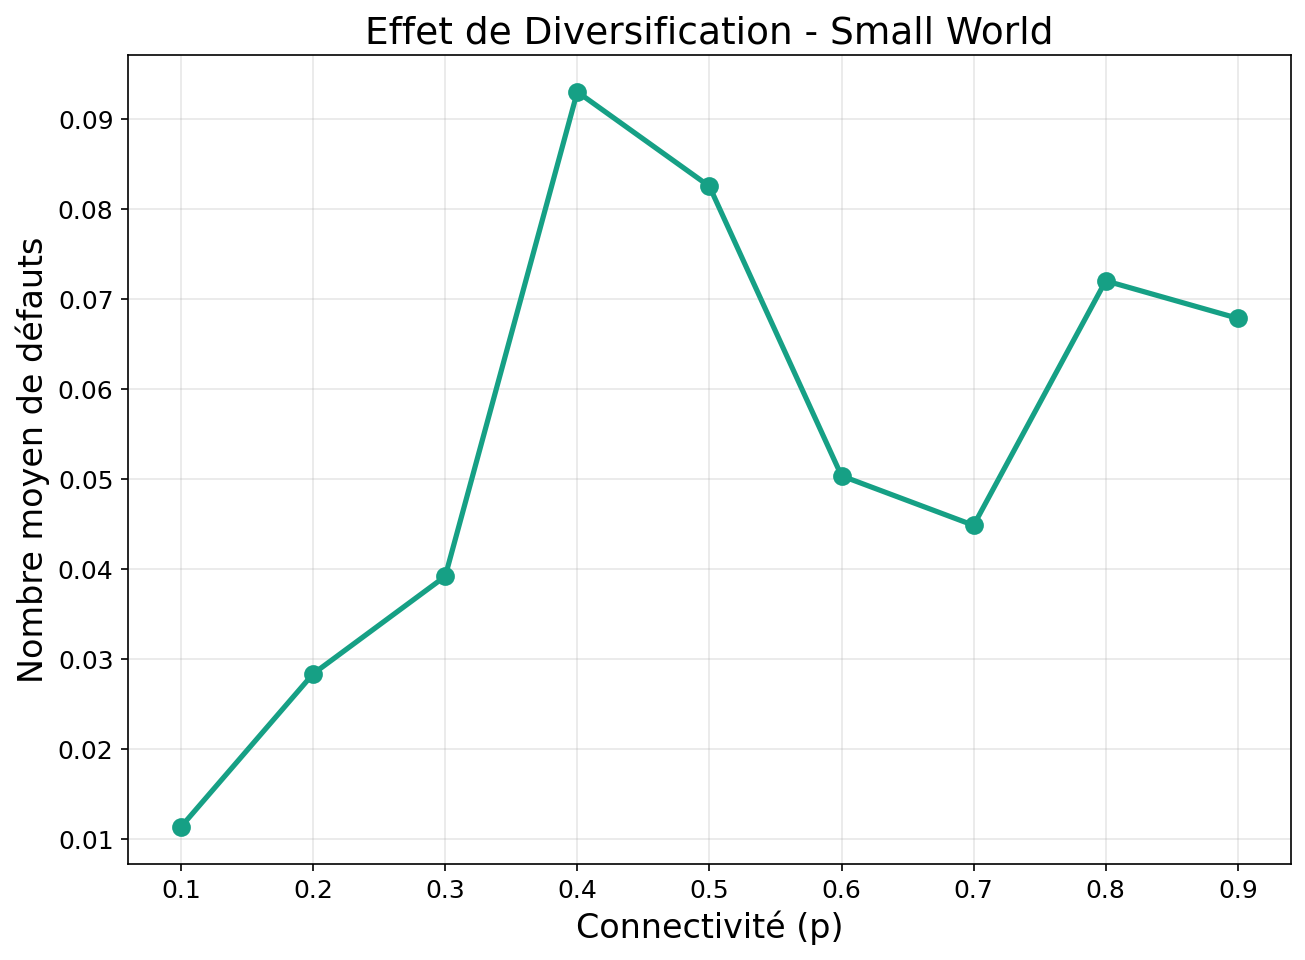

Scale-Free...


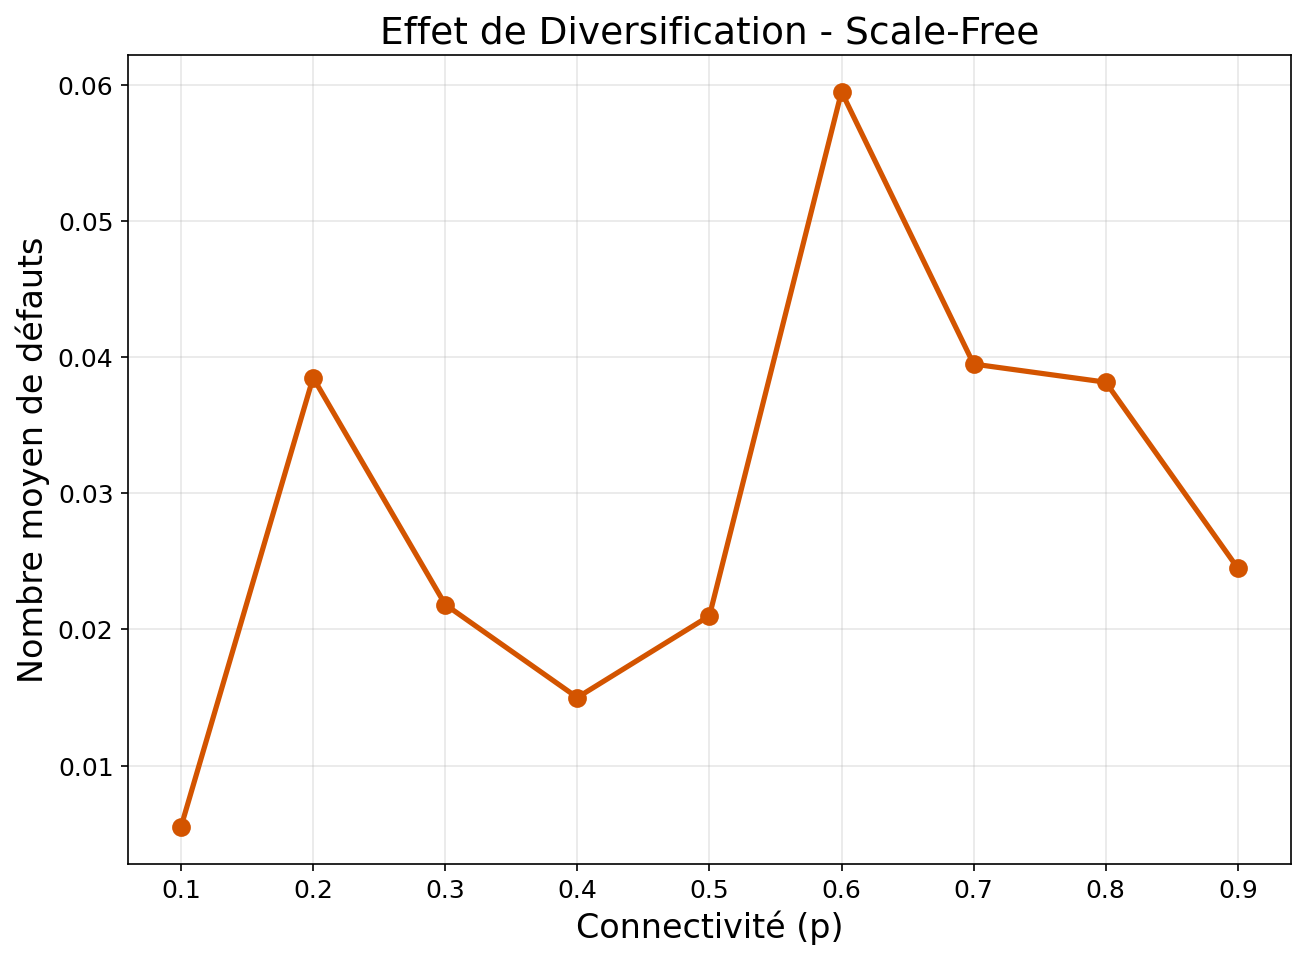


2. NON-MONOTONICITÉ
p = 0.1...
p = 0.3...
p = 0.5...
p = 0.7...
p = 0.9...


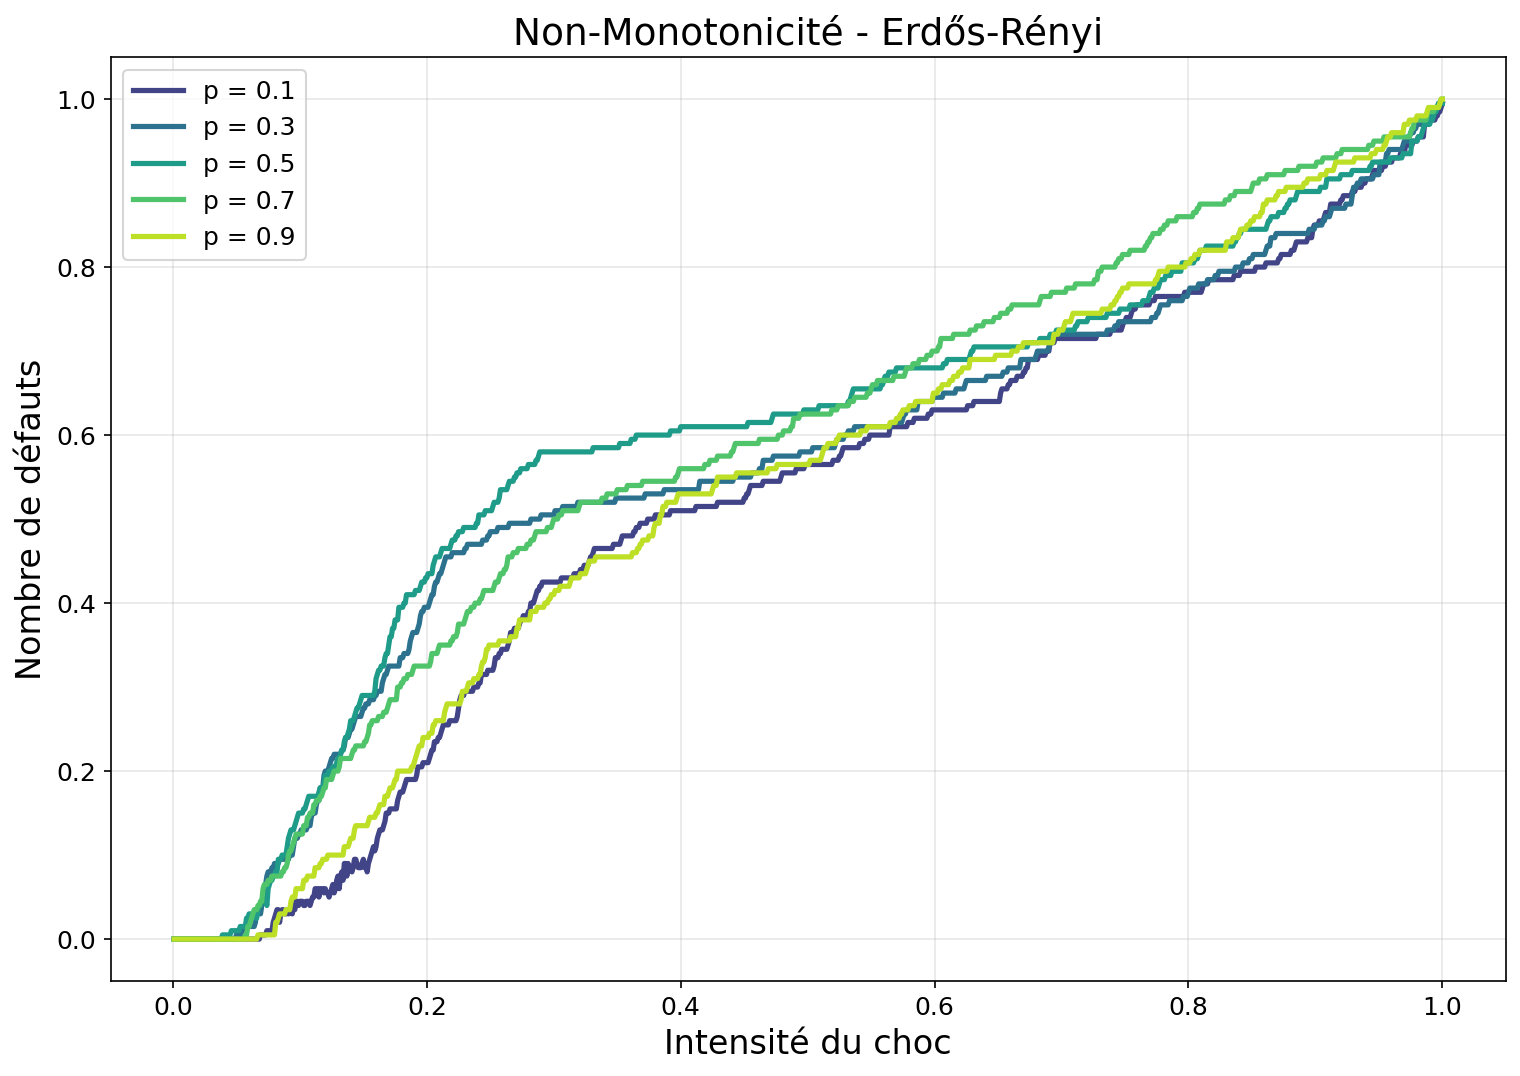

p = 0.1...
p = 0.3...
p = 0.5...
p = 0.7...
p = 0.9...


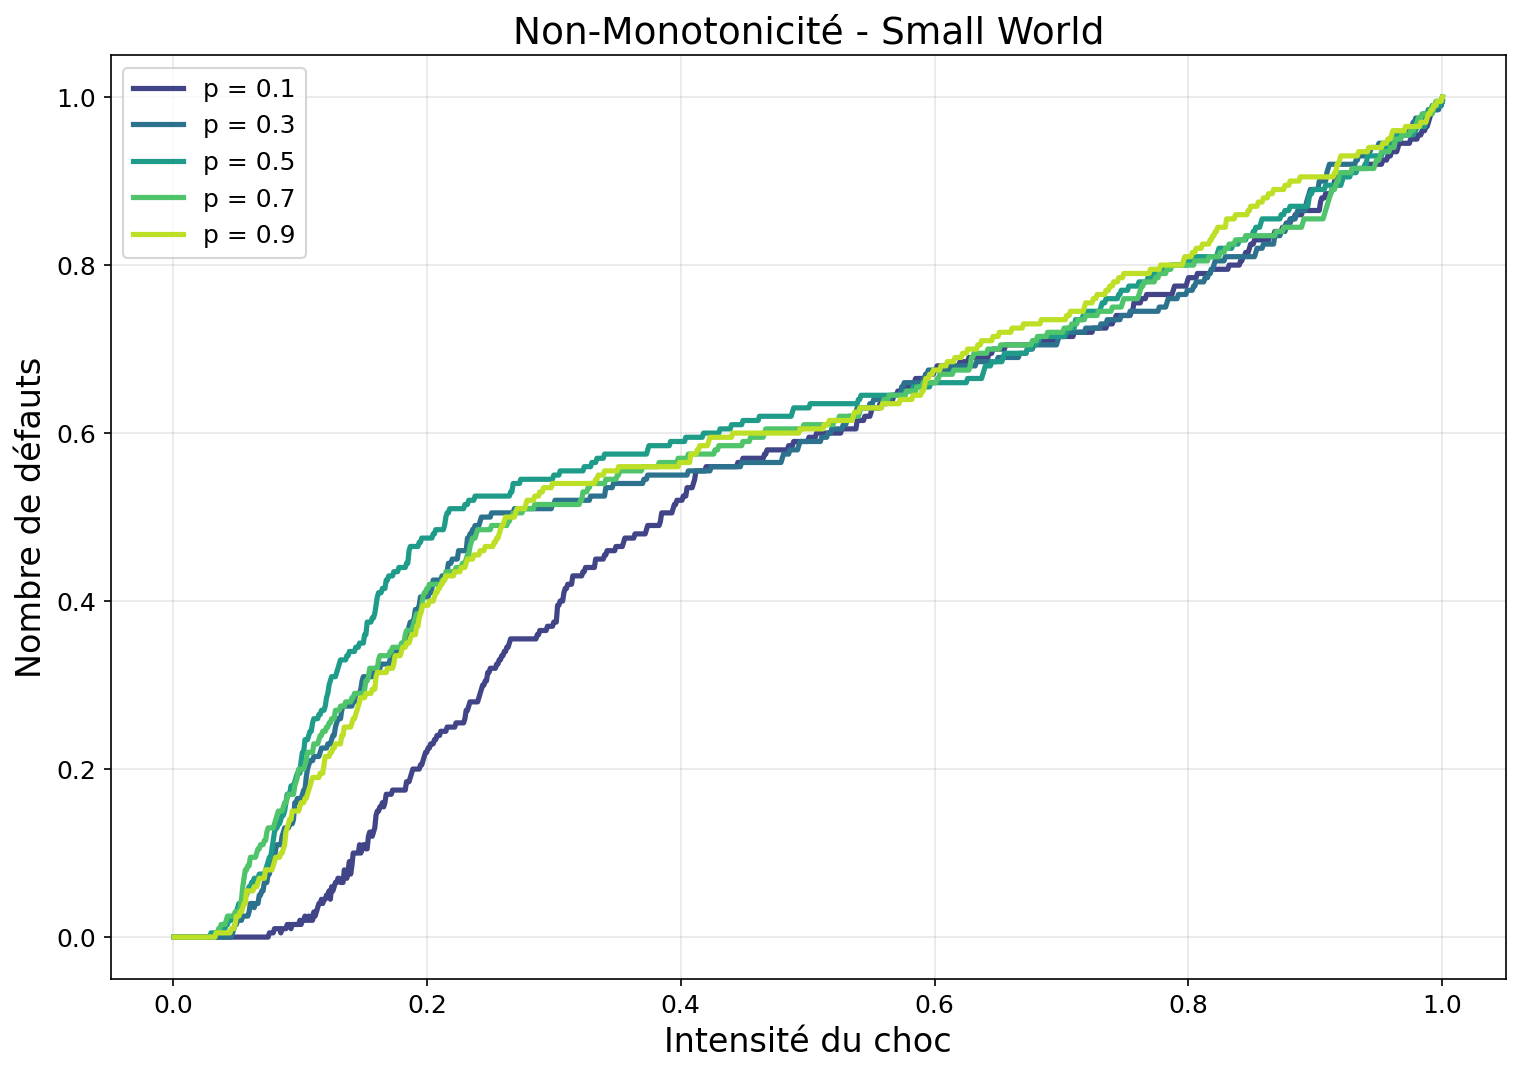

p = 0.1...
p = 0.3...
p = 0.5...
p = 0.7...
p = 0.9...


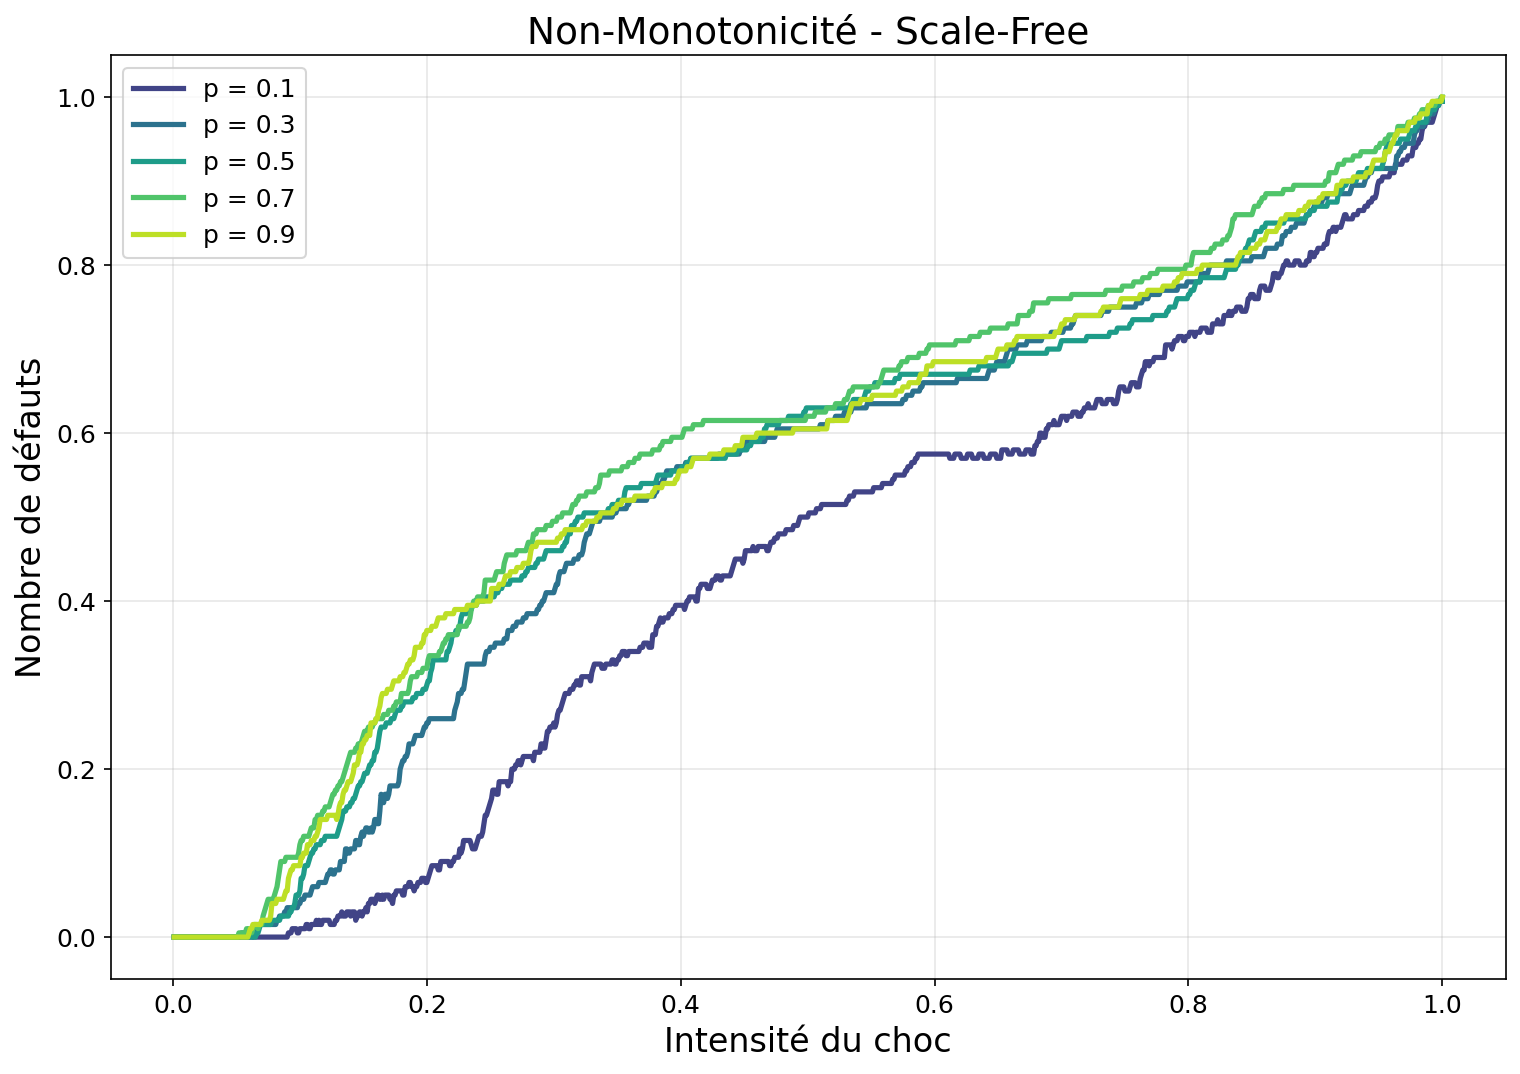


3. COMPARAISON DES TOPOLOGIES
Erdős-Rényi...
Small World...
Scale-Free...


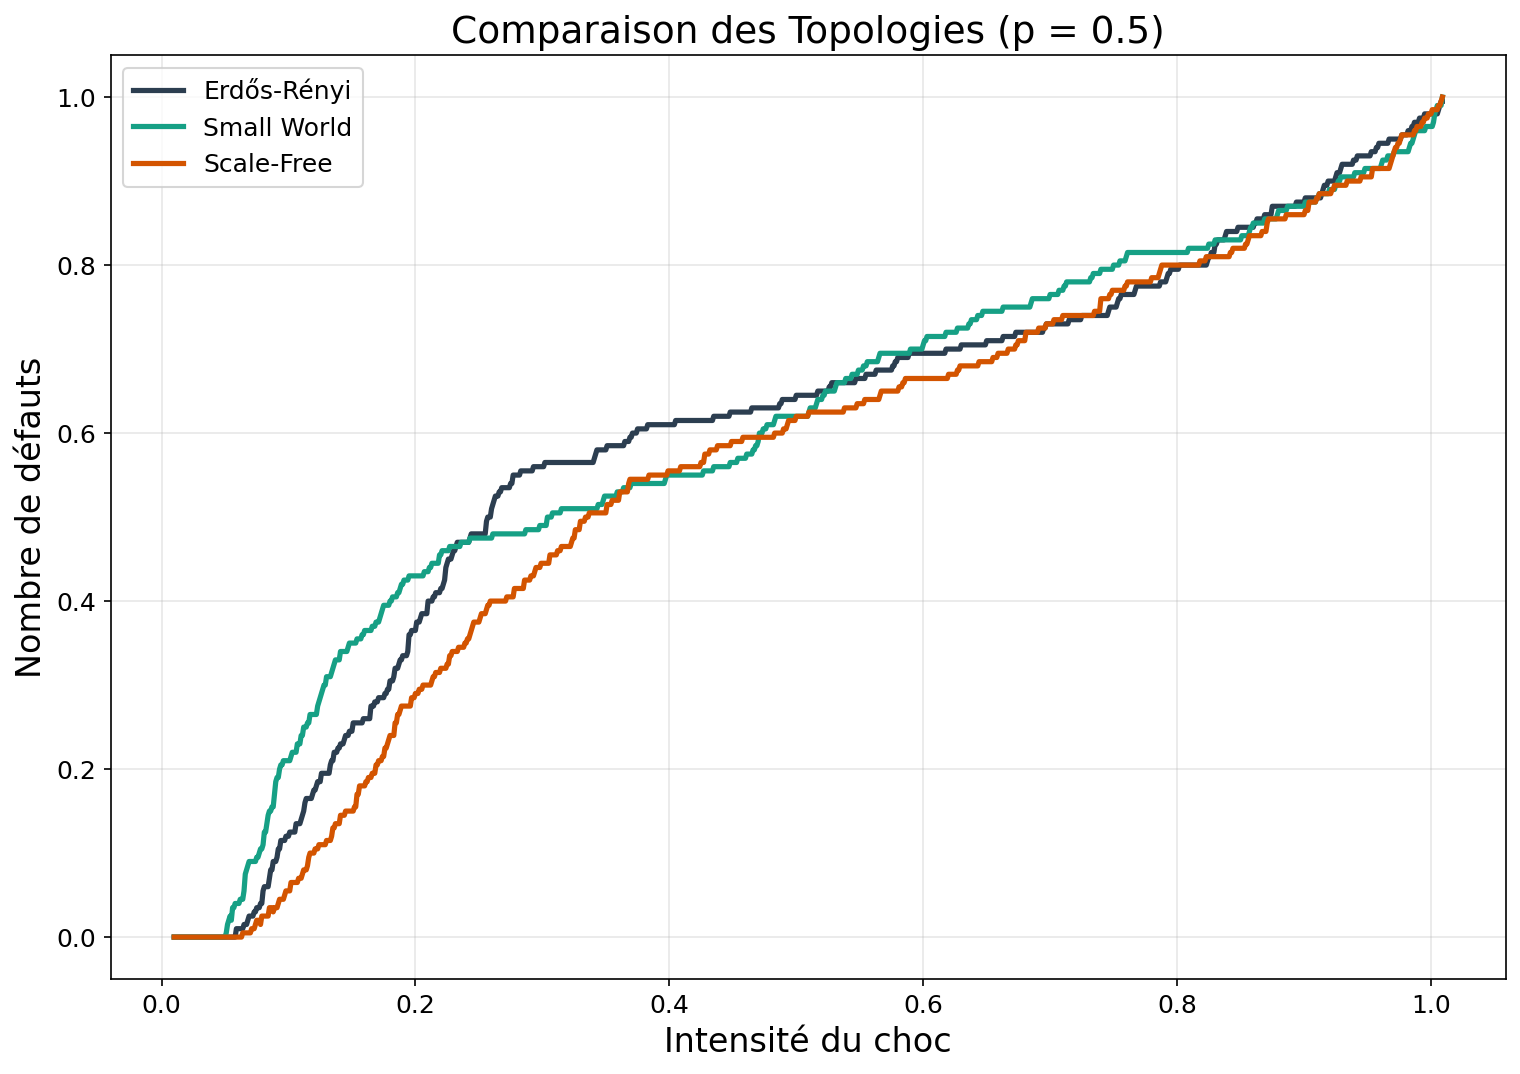


MÉTRIQUES DE CONNECTIVITÉ (200 banques, p=0.5)

Erdős-Rényi:
  Densité: 0.5017
  Degré moyen: 199.67
  Clustering: 0.5016
  Degré max: 230
  Variance degré: 94.22

Small World:
  Densité: 0.5724
  Degré moyen: 227.83
  Clustering: 0.5724
  Degré max: 241
  Variance degré: 25.66

Scale-Free:
  Densité: 0.2264
  Degré moyen: 90.11
  Clustering: 0.3103
  Degré max: 194
  Variance degré: 1413.39

✅ Graphiques générés dans 'figures_rapport/'


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration pour le rapport - haute qualité
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'axes.grid': True
})

# =========================================================================
# 1. EFFET DE DIVERSIFICATION - CHOC CORRÉLÉ avec Monte Carlo
# =========================================================================

def plot_diversification_effect(n_simulations=30):
    """
    Effet de diversification avec choc corrélé.
    Monte Carlo pour avoir des courbes lisses.
    """

    probs = np.arange(0.1, 1.0, 0.1, dtype=float)

    topologies = [
        (NetworkTopology.ERDOS_RENYI, "Erdős-Rényi", '#2C3E50'),
        (NetworkTopology.SMALL_WORLD, "Small World", '#16A085'),
        (NetworkTopology.SCALE_FREE, "Scale-Free", '#D35400')
    ]

    for topology_enum, topology_name, color in topologies:
        print(f"{topology_name}...")

        mean_defaults = []

        for prob in probs:
            defaults_list = []

            # Monte Carlo pour lisser
            for _ in range(n_simulations):
                network = BankingNetwork(200, topology_enum, probability_of_linking=prob)

                # Choc corrélé
                shock_model = CorrelatedShockModel(correlation_strength=0.4)
                shock_vector, _ = shock_model.generate_shock(network)

                n_defaults = network.count_defaults(shock_vector)
                defaults_list.append(n_defaults)

            mean_defaults.append(np.mean(defaults_list))

        # Plot simple avec ligne lisse grâce au Monte Carlo
        plt.figure(figsize=(10, 7))
        plt.plot(probs, mean_defaults, 'o-', color=color, markersize=8)
        plt.xlabel('Connectivité (p)')
        plt.ylabel('Nombre moyen de défauts')
        plt.title(f'Effet de Diversification - {topology_name}')
        plt.grid(True)
        plt.savefig(f'figures_rapport/diversification_{topology_name.lower().replace(" ", "_")}.pdf',
                   bbox_inches='tight')
        plt.show()

# =========================================================================
# 2. NON-MONOTONICITÉ - EXACTEMENT COMME VOTRE CODE
# =========================================================================

def plot_non_monotonicity_erdos():
    """
    Non-monotonicité pour Erdős-Rényi - code simple et direct.
    """

    probs = np.arange(0.1, 1.0, 0.2, dtype=float)
    dict_plot = {}
    plot_shock = np.arange(0.001, 1.001, 0.001, dtype=float)

    for prob in probs:
        print(f"p = {prob:.1f}...")
        mean_default = []
        network = BankingNetwork(200, NetworkTopology.ERDOS_RENYI, probability_of_linking=prob)
        temp = network.vector_outside_asset / 1000

        for k in range(1, 1001):
            shock_vector = k * temp
            mean_default.append(network.count_defaults(shock_vector))
        dict_plot[prob] = mean_default

    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(probs)))

    for i, prob in enumerate(probs):
        plt.plot(plot_shock, dict_plot[prob], label=f'p = {prob:.1f}',
                color=colors[i])

    plt.xlabel('Intensité du choc')
    plt.ylabel('Nombre de défauts')
    plt.title('Non-Monotonicité - Erdős-Rényi')
    plt.legend()
    plt.grid(True)
    plt.savefig('figures_rapport/non_monotonicity_erdos.pdf', bbox_inches='tight')
    plt.show()

def plot_non_monotonicity_small_world():
    """
    Non-monotonicité pour Small World.
    """

    probs = np.arange(0.1, 1.0, 0.2, dtype=float)
    dict_plot = {}
    plot_shock = np.arange(0.001, 1.001, 0.001, dtype=float)

    for prob in probs:
        print(f"p = {prob:.1f}...")
        mean_default = []
        network = BankingNetwork(200, NetworkTopology.SMALL_WORLD, probability_of_linking=prob)
        temp = network.vector_outside_asset / 1000

        for k in range(1, 1001):
            shock_vector = k * temp
            mean_default.append(network.count_defaults(shock_vector))
        dict_plot[prob] = mean_default

    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(probs)))

    for i, prob in enumerate(probs):
        plt.plot(plot_shock, dict_plot[prob], label=f'p = {prob:.1f}',
                color=colors[i])

    plt.xlabel('Intensité du choc')
    plt.ylabel('Nombre de défauts')
    plt.title('Non-Monotonicité - Small World')
    plt.legend()
    plt.grid(True)
    plt.savefig('figures_rapport/non_monotonicity_small_world.pdf', bbox_inches='tight')
    plt.show()

def plot_non_monotonicity_scale_free():
    """
    Non-monotonicité pour Scale-Free.
    """

    probs = np.arange(0.1, 1.0, 0.2, dtype=float)
    dict_plot = {}
    plot_shock = np.arange(0.001, 1.001, 0.001, dtype=float)

    for prob in probs:
        print(f"p = {prob:.1f}...")
        mean_default = []
        network = BankingNetwork(200, NetworkTopology.SCALE_FREE, probability_of_linking=prob)
        temp = network.vector_outside_asset / 1000

        for k in range(1, 1001):
            shock_vector = k * temp
            mean_default.append(network.count_defaults(shock_vector))
        dict_plot[prob] = mean_default

    plt.figure(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(probs)))

    for i, prob in enumerate(probs):
        plt.plot(plot_shock, dict_plot[prob], label=f'p = {prob:.1f}',
                color=colors[i])

    plt.xlabel('Intensité du choc')
    plt.ylabel('Nombre de défauts')
    plt.title('Non-Monotonicité - Scale-Free')
    plt.legend()
    plt.grid(True)
    plt.savefig('figures_rapport/non_monotonicity_scale_free.pdf', bbox_inches='tight')
    plt.show()

# =========================================================================
# 3. COMPARAISON SIMPLE DES TOPOLOGIES
# =========================================================================

def plot_topology_comparison():
    """
    Compare les 3 topologies sur un même graphique pour une connectivité fixe.
    """

    prob_fixed = 0.5  # Connectivité fixe
    plot_shock = np.arange(0.01, 1.01, 0.001, dtype=float)

    topologies = [
        (NetworkTopology.ERDOS_RENYI, "Erdős-Rényi", '#2C3E50'),
        (NetworkTopology.SMALL_WORLD, "Small World", '#16A085'),
        (NetworkTopology.SCALE_FREE, "Scale-Free", '#D35400')
    ]

    plt.figure(figsize=(12, 8))

    for topology_enum, topology_name, color in topologies:
        print(f"{topology_name}...")
        mean_default = []
        network = BankingNetwork(200, topology_enum, probability_of_linking=prob_fixed)
        temp = network.vector_outside_asset / 1000

        for k in range(1, 1001):
            shock_vector = k * temp
            mean_default.append(network.count_defaults(shock_vector))

        plt.plot(plot_shock, mean_default, label=topology_name, color=color)

    plt.xlabel('Intensité du choc')
    plt.ylabel('Nombre de défauts')
    plt.title(f'Comparaison des Topologies (p = {prob_fixed})')
    plt.legend()
    plt.grid(True)
    plt.savefig('figures_rapport/topology_comparison.pdf', bbox_inches='tight')
    plt.show()

def print_connectivity_metrics():
    """Affiche les métriques de connectivité pour comparaison."""

    print("\n" + "="*60)
    print("MÉTRIQUES DE CONNECTIVITÉ (200 banques, p=0.5)")
    print("="*60)

    topologies = [
        (NetworkTopology.ERDOS_RENYI, "Erdős-Rényi"),
        (NetworkTopology.SMALL_WORLD, "Small World"),
        (NetworkTopology.SCALE_FREE, "Scale-Free")
    ]

    for topology_enum, topology_name in topologies:
        network = BankingNetwork(200, topology_enum, probability_of_linking=0.5)
        metrics = network.compute_connectivity_metrics()

        print(f"\n{topology_name}:")
        print(f"  Densité: {metrics['density']:.4f}")
        print(f"  Degré moyen: {metrics['avg_degree']:.2f}")
        print(f"  Clustering: {metrics['clustering']:.4f}")
        print(f"  Degré max: {metrics['max_degree']}")
        print(f"  Variance degré: {metrics['degree_variance']:.2f}")
# =========================================================================
# FONCTION PRINCIPALE
# =========================================================================

def generate_all_plots():
    """Génère tous les graphiques pour le rapport."""

    import os
    if not os.path.exists("figures_rapport"):
        os.makedirs("figures_rapport")

    print("GÉNÉRATION DES GRAPHIQUES")
    print("-" * 40)

    # 1. Effet de diversification avec Monte Carlo (3 graphiques)
    print("\n1. EFFET DE DIVERSIFICATION")
    plot_diversification_effect(n_simulations=30)

    # 2. Non-monotonicité (3 graphiques, un par topologie)
    print("\n2. NON-MONOTONICITÉ")
    plot_non_monotonicity_erdos()
    plot_non_monotonicity_small_world()
    plot_non_monotonicity_scale_free()

    # 3. Comparaison des topologies
    print("\n3. COMPARAISON DES TOPOLOGIES")
    plot_topology_comparison()

    print_connectivity_metrics()

    print("\n✅ Graphiques générés dans 'figures_rapport/'")

# =========================================================================
# EXÉCUTION
# =========================================================================

if __name__ == "__main__":
    generate_all_plots()

100